In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import xgboost as xgb
import shap
import mlflow
import mlflow.xgboost
import os
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (mean_absolute_error,
                             mean_squared_error, r2_score,
                             classification_report, confusion_matrix)

df = pd.read_csv("../data/validated/ipo_validated.csv")
df["Date"] = pd.to_datetime(df["Date"])

print(f"Shape: {df.shape}")
print("Data loaded successfully!")

Shape: (259, 20)
Data loaded successfully!


In [2]:
# Encode performance_category as a number for ML
le = LabelEncoder()
df["performance_label"] = le.fit_transform(df["performance_category"])

print("Label encoding mapping:")
for i, cls in enumerate(le.classes_):
    print(f"  {i} → {cls}")

# Features we use to predict listing gain
FEATURES = [
    "issue_size_cr",
    "qib_subscription",
    "hni_subscription",
    "rii_subscription",
    "total_subscription",
    "issue_price",
    "nifty_30d_return",
    "Month",
    "Quarter",
    "Year"
]

# Two targets:
# 1. Regression  — predict exact listing gain %
# 2. Classification — predict performance category
TARGET_REG   = "listing_gains_pct"
TARGET_CLASS = "performance_label"

X = df[FEATURES].fillna(0)
y_reg   = df[TARGET_REG]
y_class = df[TARGET_CLASS]

print(f"\nFeatures shape: {X.shape}")
print(f"Features used: {FEATURES}")

Label encoding mapping:
  0 → Blockbuster
  1 → Loss
  2 → Moderate
  3 → Strong
  4 → Weak

Features shape: (259, 10)
Features used: ['issue_size_cr', 'qib_subscription', 'hni_subscription', 'rii_subscription', 'total_subscription', 'issue_price', 'nifty_30d_return', 'Month', 'Quarter', 'Year']


In [3]:
# 80% training, 20% testing
X_train, X_test, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

X_train_c, X_test_c, y_train_class, y_test_class = train_test_split(
    X, y_class, test_size=0.2, random_state=42
)

print(f"Training samples : {X_train.shape[0]}")
print(f"Testing samples  : {X_test.shape[0]}")

Training samples : 207
Testing samples  : 52


In [11]:
# Tell MLflow to save inside our project folder
mlflow.set_tracking_uri("file:../mlflow/runs")
mlflow.set_experiment("IPO_Listing_Gain_Prediction")

with mlflow.start_run(run_name="XGBoost_Regression"):

    reg_model = xgb.XGBRegressor(
        n_estimators    = 200,
        max_depth       = 5,
        learning_rate   = 0.05,
        subsample       = 0.8,
        colsample_bytree= 0.8,
        random_state    = 42,
        verbosity       = 0
    )

    reg_model.fit(X_train, y_train_reg)
    y_pred_reg = reg_model.predict(X_test)

    mae  = mean_absolute_error(y_test_reg, y_pred_reg)
    rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
    r2   = r2_score(y_test_reg, y_pred_reg)

    mlflow.log_params({
        "n_estimators"    : 200,
        "max_depth"       : 5,
        "learning_rate"   : 0.05,
        "subsample"       : 0.8,
        "colsample_bytree": 0.8
    })
    mlflow.log_metrics({"MAE": mae, "RMSE": rmse, "R2": r2})
    mlflow.xgboost.log_model(reg_model, "xgb_regression_model")

    print("=== XGBoost Regression Results ===")
    print(f"MAE  : {mae:.2f}%")
    print(f"RMSE : {rmse:.2f}%")
    print(f"R2   : {r2:.4f}")
    print("\nModel logged to MLflow!")

2026/03/20 15:11:40 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


=== XGBoost Regression Results ===
MAE  : 28.24%
RMSE : 40.05%
R2   : 0.0427

Model logged to MLflow!


In [12]:
mlflow.set_tracking_uri("file:../mlflow/runs")
with mlflow.start_run(run_name="XGBoost_Classifier"):

    cls_model = xgb.XGBClassifier(
        n_estimators    = 200,
        max_depth       = 5,
        learning_rate   = 0.05,
        subsample       = 0.8,
        colsample_bytree= 0.8,
        random_state    = 42,
        verbosity       = 0
    )

    cls_model.fit(X_train_c, y_train_class)

    y_pred_class = cls_model.predict(X_test_c)

    print("=== XGBoost Classifier Results ===")
    print(classification_report(
        y_test_class, y_pred_class,
        target_names=le.classes_
    ))

    mlflow.xgboost.log_model(cls_model, "xgb_classifier_model")
    print("Classifier logged to MLflow!")

2026/03/20 15:11:51 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


=== XGBoost Classifier Results ===
              precision    recall  f1-score   support

 Blockbuster       0.40      0.40      0.40         5
        Loss       0.71      0.76      0.73        29
    Moderate       0.33      0.38      0.35         8
      Strong       0.00      0.00      0.00         3
        Weak       0.40      0.29      0.33         7

    accuracy                           0.56        52
   macro avg       0.37      0.36      0.36        52
weighted avg       0.54      0.56      0.55        52

Classifier logged to MLflow!


Calculating SHAP values — this explains WHY the model predicts what it does...


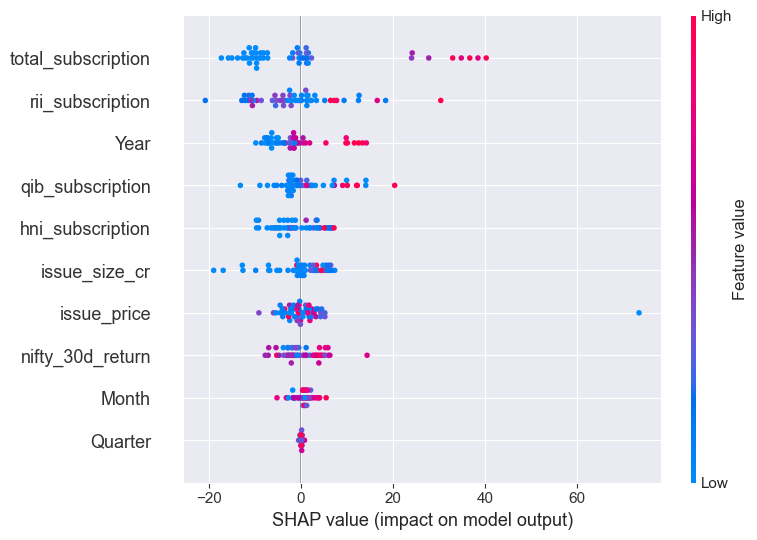

In [13]:
print("Calculating SHAP values — this explains WHY the model predicts what it does...")

explainer   = shap.Explainer(reg_model)
shap_values = explainer(X_test)

# Global feature importance
shap.summary_plot(shap_values, X_test,
                  feature_names=FEATURES,
                  show=True)

Explaining prediction for IPO index: 66
IPO Name    : Muthoot Finance
Actual gain : 0.71%
Predicted   : 8.78%


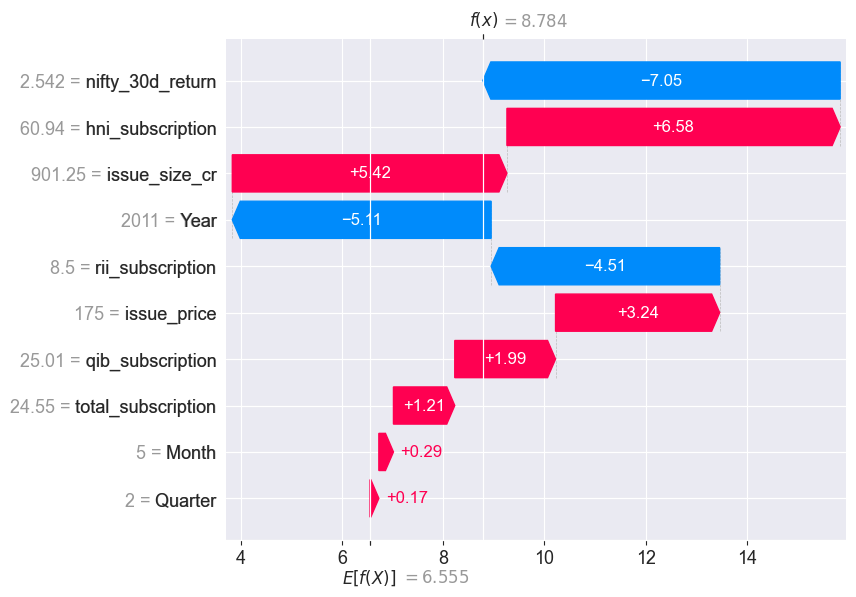

In [8]:
# Pick the first test IPO and explain its prediction
sample_idx = 0

print(f"Explaining prediction for IPO index: {X_test.index[sample_idx]}")
print(f"IPO Name    : {df.loc[X_test.index[sample_idx], 'ipo_name']}")
print(f"Actual gain : {y_test_reg.iloc[sample_idx]:.2f}%")
print(f"Predicted   : {y_pred_reg[sample_idx]:.2f}%")

shap.plots.waterfall(shap_values[sample_idx])

In [9]:
fig = px.scatter(
    x=y_test_reg,
    y=y_pred_reg,
    labels={
        "x": "Actual Listing Gain (%)",
        "y": "Predicted Listing Gain (%)"
    },
    title="Actual vs Predicted IPO Listing Gains"
)
fig.add_shape(
    type="line",
    x0=y_test_reg.min(), y0=y_test_reg.min(),
    x1=y_test_reg.max(), y1=y_test_reg.max(),
    line=dict(color="red", dash="dash")
)
fig.show()

In [10]:
import pickle
os.makedirs("../src", exist_ok=True)

# Save both models
with open("../src/xgb_regressor.pkl", "wb") as f:
    pickle.dump(reg_model, f)

with open("../src/xgb_classifier.pkl", "wb") as f:
    pickle.dump(cls_model, f)

with open("../src/label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)

with open("../src/feature_list.pkl", "wb") as f:
    pickle.dump(FEATURES, f)

print("Models saved!")
print("  src/xgb_regressor.pkl")
print("  src/xgb_classifier.pkl")
print("  src/label_encoder.pkl")
print("  src/feature_list.pkl")

Models saved!
  src/xgb_regressor.pkl
  src/xgb_classifier.pkl
  src/label_encoder.pkl
  src/feature_list.pkl
